# Elastic scattering with `LocalOpticalPotential`

This notebook demonstrates a complete elastic-scattering workflow built around the convenience `LocalOpticalPotential` interface. It is the best first example if you want to go from a built-in interaction to calculated observables quickly.


In [1]:
from jitr.reactions.reaction import Reaction

In [2]:
neutron = (1, 0)
proton = (1, 1)

In [3]:
target = (208, 82)
projectile = proton
energy_lab = 80
reaction = Reaction(target=target, projectile=projectile, process="El")
kinematics = reaction.kinematics(energy_lab)
kinematics

ChannelKinematics(Elab=80, Ecm=79.6143271413054, mu=np.float64(1012.3503270110435), k=np.float64(1.9944672808011834), eta=np.float64(1.5392055587613254))

## Use the built-in `LocalOpticalPotential` class

Although, in general, one can define whatever interaction they want. This is just a handy tool.

In [4]:
from jitr.optical_potentials import LocalOpticalPotential

help(LocalOpticalPotential)

Help on class LocalOpticalPotential in module jitr.optical_potentials.omp:

class LocalOpticalPotential(SingleChannelOpticalModel)
 |  LocalOpticalPotential(scale_radii_by_At_and_Ap: 'bool' = False) -> 'None'
 |
 |  Simple local optical potential with optional nucleus-nucleus radius scaling.
 |
 |  Method resolution order:
 |      LocalOpticalPotential
 |      SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, scale_radii_by_At_and_Ap: 'bool' = False) -> 'None'
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  evaluate(self, rgrid: 'ArrayOrScalar', reaction_model: 'reaction.Reaction', kinematics_model: 'kinematics.ChannelKinematics', Vv: 'float', rv: 'float', av: 'float', Wv: 'float', rw: 'float', aw: 'float', Wd: 'float', Vd: 'float', rd: 'float', ad: 'float', Vso: 'float', Wso: 'float', rso: 'float', aso: 'float', rC: 'float') -> 'tuple[PotentialArray, PotentialArray, PotentialArray | ArrayOrScalar]'
 |    

In [5]:
omp = LocalOpticalPotential()
omp.params

['Vv',
 'rv',
 'av',
 'Wv',
 'rw',
 'aw',
 'Wd',
 'Vd',
 'rd',
 'ad',
 'Vso',
 'Wso',
 'rso',
 'aso',
 'rC']

## Randomly generate a bunch of parameters
In reality, we would like to fit these to data

In [6]:
import numpy as np

means = np.array([56, 1.2, 0.7, 5, 1.2, 0.7, 13, 6, 1.3, 0.9, 8, 4, 1.1, 0.7, 1.2])
cov = np.diag((means * 0.01) ** 2)
samples = np.random.multivariate_normal(means, cov, 1000)

In [7]:
from pandas import DataFrame

df = DataFrame(samples, columns=omp.params)
df.head()

,Vv,rv,av,Wv,rw,aw,Wd,Vd,rd,ad,Vso,Wso,rso,aso,rC
0,56.008680,1.184187,0.706418,5.025594,1.203299,0.711824,12.840608,5.879121,1.301646,0.902640,7.962687,4.005459,1.110951,0.695559,1.174910
1,56.084818,1.180728,0.694989,5.032721,1.196486,0.701398,13.032553,5.897335,1.288625,0.907028,7.944506,4.006843,1.086645,0.692567,1.202895
2,56.710843,1.236511,0.694625,4.977382,1.187840,0.688709,13.122953,6.009036,1.312488,0.927448,8.118641,4.077431,1.090889,0.704296,1.205484
3,55.586370,1.220952,0.696721,4.959736,1.192569,0.700539,13.111023,5.904910,1.279295,0.890192,7.914496,4.008934,1.079809,0.705618,1.203005
4,56.905577,1.203284,0.694475,4.962189,1.211859,0.702717,13.040253,6.054403,1.276774,0.894719,8.015655,3.917434,1.082029,0.700222,1.199441


## How do we calculate observables? 
We will use `jitr.xs.elastic.DifferentialWorkspace`. We will see how this is set up to interface with `omp` and other classes that have the same structure

In [8]:
from jitr.xs import elastic

help(elastic.DifferentialWorkspace.xs)

Help on function xs in module jitr.xs.elastic:

xs(self, central_potential: 'npt.ArrayLike', spin_orbit_potential: 'npt.ArrayLike', coulomb_potential: 'npt.ArrayLike | None' = None) -> 'ElasticXS'
    Return differential and integral elastic observables.



Exactly the information that the solver workspace needs is what is provided by the `omp` class:

In [9]:
help(omp.evaluate)

Help on method evaluate in module jitr.optical_potentials.omp:

evaluate(rgrid: 'ArrayOrScalar', reaction_model: 'reaction.Reaction', kinematics_model: 'kinematics.ChannelKinematics', Vv: 'float', rv: 'float', av: 'float', Wv: 'float', rw: 'float', aw: 'float', Wd: 'float', Vd: 'float', rd: 'float', ad: 'float', Vso: 'float', Wso: 'float', rso: 'float', aso: 'float', rC: 'float') -> 'tuple[PotentialArray, PotentialArray, PotentialArray | ArrayOrScalar]' method of jitr.optical_potentials.omp.LocalOpticalPotential instance
    Evaluate the local optical-potential terms on ``rgrid``.



## Do you see the vision?
Let's set up a solver and see this thing in action.

In [10]:
from jitr.rmatrix import Solver as SolverKernel

In [11]:
solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=30,
    solver=SolverKernel(50),
    lmax=80,
    angles=np.linspace(0.1, np.pi, 180),
)

Now running calculations is simple!
Once it's been compiled, it's fast:

In [12]:
from tqdm import tqdm

In [13]:
%%time
num_samples, num_params = df.shape
xs_ratio = np.zeros((num_samples, solver.angles.size))
Ay = np.zeros((num_samples, solver.angles.size))
rgrid = solver.radial_grid()

for i in tqdm(range(num_samples)):
    central_term, spin_orbit_term, coulomb_term = omp(
        rgrid,
        reaction,
        kinematics,
        *samples[i, :],
    )
    xs = solver.xs(central_term, spin_orbit_term, coulomb_term)
    xs_ratio[i, :] = xs.dsdo / solver.rutherford
    Ay[i, :] = xs.Ay

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:30<00:00, 33.02it/s]

CPU times: user 30 s, sys: 336 ms, total: 30.3 s
Wall time: 30.3 s


In [14]:
from matplotlib import pyplot as plt

Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{\\text{R}}}{d\\Omega}$ [dimensionless]')

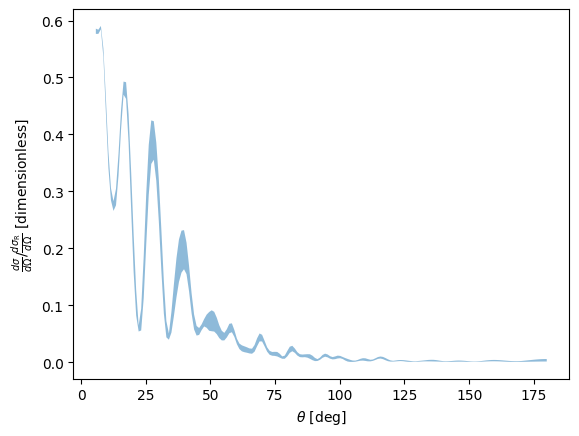

In [15]:
l, h = np.percentile(xs_ratio, [5, 95], axis=0)
plt.fill_between(np.rad2deg(solver.angles), l, h, alpha=0.5)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(
    r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{\text{R}}}{d\Omega}$ [dimensionless]"
)

Text(0, 0.5, '$A_y$ [dimensionless]')

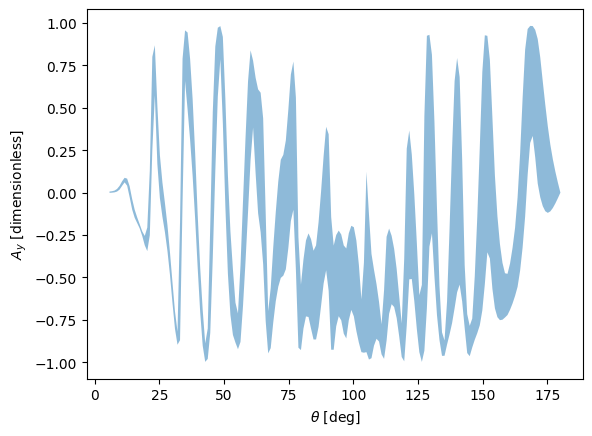

In [16]:
l, h = np.percentile(Ay, [5, 95], axis=0)
plt.fill_between(np.rad2deg(solver.angles), l, h, alpha=0.5)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$A_y$ [dimensionless]")